## EDA

## Part 1 - Understanding your data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\user\Downloads\Titanic-Dataset.csv')

In [3]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Finding nulls and duplicates

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

## Part 2 - Visualization

Histogram — distribution of a numerical column:

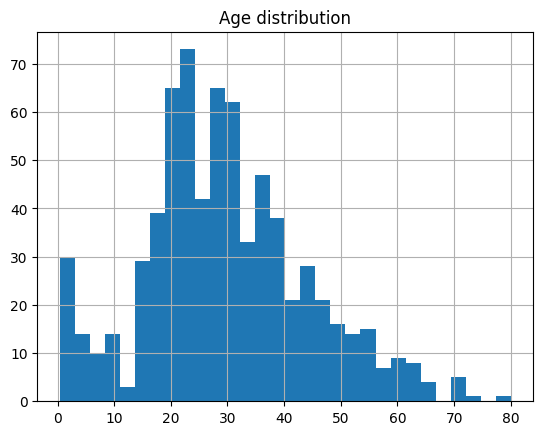

In [13]:
df['Age'].hist(bins = 30)
plt.title('Age distribution')
plt.show()

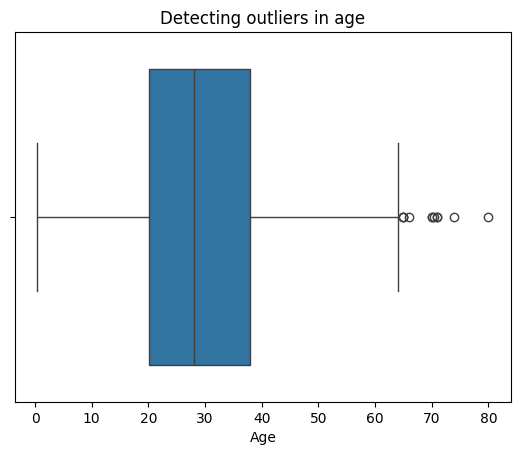

In [16]:
sns.boxplot(x=df['Age'])
plt.title('Detecting outliers in age')
plt.show()

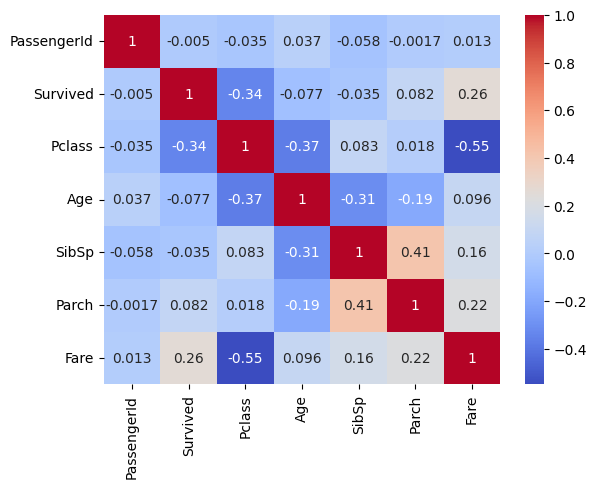

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Feature Engineering

## Step 1 — Check Missing Values First

In [19]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Strategy for each:

Age → fill with median (because Age has outliers, median is safer than mean)
Cabin → drop the column (77% missing, not worth keeping)
Embarked → fill with mode (most frequent value, since only 2 missing)

In [20]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns = ['Cabin'],inplace = True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [21]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Step 2: Outlier Treatment

In [22]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower limit: {lower}")
print(f"Upper limit: {upper}")
print(f"Outliers: {df[(df['Age'] < lower) | (df['Age'] > upper)].shape[0]}")

Lower limit: 2.5
Upper limit: 54.5
Outliers: 66


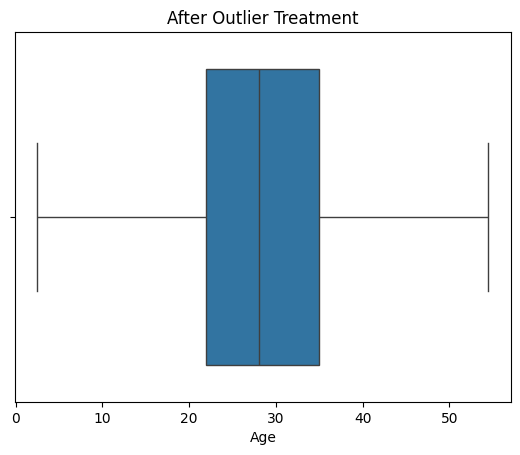

In [23]:
df['Age'] = df['Age'].clip(lower=lower, upper=upper)

# Verify with boxplot
sns.boxplot(x=df['Age'])
plt.title('After Outlier Treatment')
plt.show()

## Step 3: Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
df['Age_scaled']=scaler.fit_transform(df[['Age']])
df['Fare_scaled']=scaler.fit_transform(df[['Fare']])
print(df[['Age', 'Age_scaled', 'Fare', 'Fare_scaled']].head(10))

    Age  Age_scaled     Fare  Fare_scaled
0  22.0   -0.583432   7.2500    -0.502445
1  38.0    0.742685  71.2833     0.786845
2  26.0   -0.251903   7.9250    -0.488854
3  35.0    0.494038  53.1000     0.420730
4  35.0    0.494038   8.0500    -0.486337
5  28.0   -0.086138   8.4583    -0.478116
6  54.0    2.068803  51.8625     0.395814
7   2.5   -2.199638  21.0750    -0.224083
8  27.0   -0.169020  11.1333    -0.424256
9  14.0   -1.246491  30.0708    -0.042956


## Step 4: Encoding

In [28]:
df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [29]:
df.drop(columns=['Name', 'Ticket'], inplace=True)   #dropping useless columns name and ticket which is not used by model

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df['Sex'].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [31]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Age_scaled', 'Fare_scaled', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

## Step 5: Feature Selection

In [32]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Age_scaled', 'Fare_scaled', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [33]:
df.drop(columns=['Age', 'Fare', 'PassengerId'], inplace=True)

df.columns

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Age_scaled',
       'Fare_scaled', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [34]:
correlation = df.corr()['Survived'].sort_values(ascending=False)
print(correlation)

Survived       1.000000
Fare_scaled    0.257307
Parch          0.081629
Embarked_Q     0.003650
SibSp         -0.035322
Age_scaled    -0.060622
Embarked_S    -0.149683
Pclass        -0.338481
Sex           -0.543351
Name: Survived, dtype: float64


Most important columns for predicting Survived:

Sex = -0.54 → strongest! Female survived more
Pclass = -0.33 → higher class number = less survival
Fare_scaled = 0.26 → paid more = survived more
Embarked_S = -0.15 → moderate


Least useful columns:

Embarked_Q = 0.003 → almost 0, useless
SibSp = -0.035 → almost 0, useless
Parch = 0.08 → very weak

In [41]:
# df.drop(columns=['Embarked_Q', 'SibSp', 'Parch'], inplace=True)

# df.columns

## Split data into X and Y

In [37]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print(X.shape)
print(y.shape)

(891, 5)
(891,)


## Split into train and test

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(712, 5)
(179, 5)


## Train the model

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Prediction and Accuracy

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7988826815642458

Confusion Matrix:
 [[88 17]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

